In [1]:
pip install torch torchvision torchaudio librosa numpy pandas matplotlib seaborn scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==========================================
CONFIG = {
    'dataset_path': r"E:\Extra_Work\SLITT\MySolution\AI\Training\Emotion_Voice_Datasets\RAVDESS",
    'sample_rate': 22050,
    'duration': 3,          # Seconds
    'n_mfcc': 40,           # Number of MFCCs
    'batch_size': 32,
    'epochs': 200,
    'learning_rate': 0.001,
    'weight_decay': 0.0001, # L2 Regularization
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# RAVDESS Emotion Dictionary
EMOTIONS = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}



Using device: cuda


In [4]:
# ==========================================
# 2. DATA PREPARATION (EDA & PROCESSING)
# ==========================================
def load_file_paths(path):
    file_list = []
    label_list = []
    
    print("Scanning files...")
    # Recursively find all .wav files
    for file in glob.glob(os.path.join(path, "**/*.wav"), recursive=True):
        filename = os.path.basename(file)
        parts = filename.split("-")
        
        if len(parts) == 7:
            emotion_code = parts[2]
            label = EMOTIONS.get(emotion_code)
            if label:
                file_list.append(file)
                label_list.append(label)
                
    return pd.DataFrame({'path': file_list, 'label': label_list})

def extract_features(file_path):
    """
    Extracts MFCC features.
    Returns shape: (n_mfcc, time_steps) -> Suitable for PyTorch Conv1D (Channels, Length)
    """
    target_len = CONFIG['sample_rate'] * CONFIG['duration']
    
    try:
        audio, sr = librosa.load(file_path, sr=CONFIG['sample_rate'], duration=CONFIG['duration'])
        
        # Pad or Truncate
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)), 'constant')
        else:
            audio = audio[:target_len]
            
        # Extract MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=CONFIG['n_mfcc'])
        return mfcc
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

# --- Execution ---
df = load_file_paths(CONFIG['dataset_path'])
print(f"Found {len(df)} files.")

# Pre-extract features into RAM (RAVDESS is small enough for this)
print("Extracting features (this may take a moment)...")
X_raw = []
valid_indices = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing Audio"):
    feat = extract_features(row['path'])
    if feat is not None:
        X_raw.append(feat)
        valid_indices.append(idx)

X = np.array(X_raw)
y = df.loc[valid_indices, 'label'].values

# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standard Scaling
# Flatten (N, 40, Time) -> (N, 40 * Time) for scaling, then reshape back
# Note: Usually better to scale across the time dimension per channel, 
# but global scaling is standard for simple SER.
scaler = StandardScaler()
N, C, T = X_train.shape

X_train = X_train.reshape(N, -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X_train = scaler.fit_transform(X_train).reshape(N, C, T)
X_test = scaler.transform(X_test).reshape(X_test.shape[0], C, T)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")



Scanning files...
Found 1440 files.
Extracting features (this may take a moment)...


Processing Audio: 100%|██████████| 1440/1440 [00:23<00:00, 61.11it/s]


Train shape: (1152, 40, 130) | Test shape: (288, 40, 130)


In [5]:
# ==========================================
# 3. PYTORCH DATASET & DATALOADER
# ==========================================
class RAVDESSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = RAVDESSDataset(X_train, y_train)
test_dataset = RAVDESSDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)



In [6]:
# ==========================================
# 4. MODEL DEFINITION (1D CNN)
# ==========================================
class SERModel(nn.Module):
    def __init__(self, num_classes, input_channels):
        super(SERModel, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv1d(input_channels, 256, kernel_size=8, padding=4),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
            
            # Block 2
            nn.Conv1d(256, 128, kernel_size=8, padding=4),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
            
            # Block 3
            nn.Conv1d(128, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
            
            # Block 4
            nn.Conv1d(64, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
        )
        
        self.flatten = nn.Flatten()
        
        # Compute shape after conv layers dynamically to avoid math errors
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, X_train.shape[2])
            dummy_output = self.conv_layers(dummy_input)
            self.flatten_dim = dummy_output.view(1, -1).shape[1]
            
        self.dense_layers = nn.Sequential(
            nn.Linear(self.flatten_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.dense_layers(x)
        return x

model = SERModel(num_classes=len(classes), input_channels=CONFIG['n_mfcc']).to(CONFIG['device'])
print(model)



SERModel(
  (conv_layers): Sequential(
    (0): Conv1d(40, 256, kernel_size=(8,), stride=(1,), padding=(4,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(256, 128, kernel_size=(8,), stride=(1,), padding=(4,))
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(128, 64, kernel_size=(8,), stride=(1,), padding=(4,))
    (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.2, inplace=False)
    (15): Conv1d(64, 64, kernel_size=(8,), stride=(1,), pad


Starting Training with Early Stopping...


Epoch 1: Train Loss: 1.8726, Val Loss: 1.6747, Val Acc: 0.3611


Epoch 2: Train Loss: 1.5521, Val Loss: 1.5155, Val Acc: 0.4028


Epoch 3: Train Loss: 1.3372, Val Loss: 1.4442, Val Acc: 0.4757


Epoch 4: Train Loss: 1.1936, Val Loss: 1.4367, Val Acc: 0.4583


...

Epoch 21: Train Loss: 0.1531, Val Loss: 1.1066, Val Acc: 0.6632
Early Stopping Counter: 3/7


Epoch 22: Train Loss: 0.1647, Val Loss: 1.1529, Val Acc: 0.6771
Early Stopping Counter: 4/7


Epoch 23: Train Loss: 0.1610, Val Loss: 1.1630, Val Acc: 0.7049
Early Stopping Counter: 5/7


Epoch 24: Train Loss: 0.1091, Val Loss: 1.1670, Val Acc: 0.6875
Early Stopping Counter: 6/7


Epoch 25: Train Loss: 0.1443, Val Loss: 1.3346, Val Acc: 0.7014
Early Stopping Counter: 7/7
Early stopping triggered! Model has stopped improving.


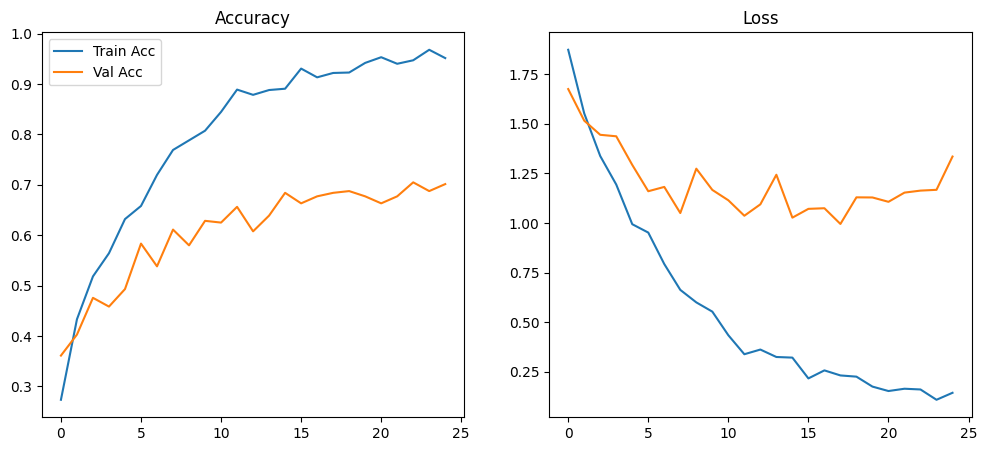

In [7]:
# ==========================================
# 5. TRAINING LOOP (WITH EARLY STOPPING)
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# --- Early Stopping Parameters ---
patience = 7               
counter = 0                
best_val_loss = float('inf') # Initialize with infinity

best_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\nStarting Training with Early Stopping...")
for epoch in range(CONFIG['epochs']):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Train Loop
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}", leave=False)
    for inputs, labels in loop:
        inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        loop.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    # Validation Loop
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_epoch_loss = val_loss / len(test_loader)
    val_epoch_acc = val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc)
    
    # --- Learning Rate Scheduler ---
    # We check if LR changed manually to print it
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_epoch_acc)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr != current_lr:
        print(f"Epoch {epoch+1}: LR reduced from {current_lr} to {new_lr}")
    
    # --- Model Checkpointing (Best Accuracy) ---
    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        torch.save(model.state_dict(), "best_ser_model.pth")
        
    print(f"Epoch {epoch+1}: Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

    # --- Early Stopping Logic ---
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        counter = 0  # Reset counter if validation loss improves
    else:
        counter += 1
        print(f"Early Stopping Counter: {counter}/{patience}")
        
        if counter >= patience:
            print("Early stopping triggered! Model has stopped improving.")
            break

# Plotting Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss')
plt.show()


Loading Best Model for Evaluation...


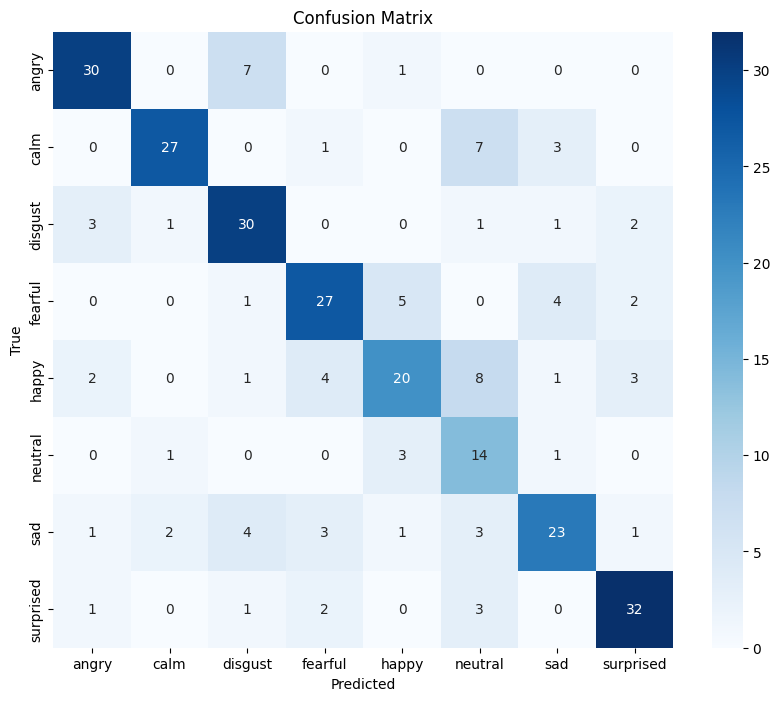


Classification Report:
              precision    recall  f1-score   support

       angry       0.81      0.79      0.80        38
        calm       0.87      0.71      0.78        38
     disgust       0.68      0.79      0.73        38
     fearful       0.73      0.69      0.71        39
       happy       0.67      0.51      0.58        39
     neutral       0.39      0.74      0.51        19
         sad       0.70      0.61      0.65        38
   surprised       0.80      0.82      0.81        39

    accuracy                           0.70       288
   macro avg       0.71      0.71      0.70       288
weighted avg       0.73      0.70      0.71       288



In [8]:
# ==========================================
# 6. EVALUATION
# ==========================================
print("\nLoading Best Model for Evaluation...")
model.load_state_dict(torch.load("best_ser_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(CONFIG['device'])
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))



In [9]:
# ==========================================
# 7. INFERENCE PIPELINE
# ==========================================
def predict_emotion(audio_path, model, scaler, le):
    model.eval()
    
    # 1. Extract Features
    mfcc = extract_features(audio_path)
    if mfcc is None: return "Error"
    
    # 2. Scale Features
    # (Channels, Time) -> Flatten -> Scale -> Reshape -> Add Batch Dim -> (1, Channels, Time)
    C, T = mfcc.shape
    mfcc_flat = mfcc.reshape(-1).reshape(1, -1)
    mfcc_scaled = scaler.transform(mfcc_flat).reshape(1, C, T)
    
    # 3. Convert to Tensor
    input_tensor = torch.tensor(mfcc_scaled, dtype=torch.float32).to(CONFIG['device'])
    
    # 4. Predict
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
    predicted_emotion = le.inverse_transform([predicted_idx.item()])[0]
    return predicted_emotion, confidence.item()



In [10]:
# Test on a random file from dataset
test_file = r"E:\Extra_Work\SLITT\MySolution\AI\Training\output_song.wav"
print(f"\nInference on: {os.path.basename(test_file)}")
pred, conf = predict_emotion(test_file, model, scaler, le)
print(f"Prediction: {pred} (Confidence: {conf:.2f})")


Inference on: output_song.wav
Prediction: fearful (Confidence: 0.48)


Using device: cuda
Scanning dataset...
Found 1440 audio files.
Extracting features...


Processing: 100%|██████████| 1440/1440 [00:19<00:00, 74.61it/s]
C:\Users\LOQ\AppData\Local\Temp\ipykernel_31776\3322525064.py:215: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler() # For Mixed Precision Training


Data Shapes -> Train: (1152, 40, 130), Test: (288, 40, 130)

Starting Training...


Epoch 1/150:   0%|          | 0/36 [00:00<?, ?it/s]C:\Users\LOQ\AppData\Local\Temp\ipykernel_31776\3322525064.py:240: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CONFIG['device'] == 'cuda')):


Epoch 1: Train Loss: 1.9666 | Val Loss: 1.7913 | Val Acc: 0.2986


...

Epoch 21: Train Loss: 0.6585 | Val Loss: 1.5497 | Val Acc: 0.5347
Early Stopping Counter: 4/8


Epoch 22: Train Loss: 0.6535 | Val Loss: 1.7677 | Val Acc: 0.5069
Early Stopping Counter: 5/8


Epoch 23: Train Loss: 0.5356 | Val Loss: 1.2859 | Val Acc: 0.6181
Early Stopping Counter: 6/8


Epoch 24: Train Loss: 0.5027 | Val Loss: 1.3310 | Val Acc: 0.5764
Early Stopping Counter: 7/8


Epoch 25: Train Loss: 0.4425 | Val Loss: 1.2895 | Val Acc: 0.6146
Early Stopping Counter: 8/8
Early Stopping Triggered.

--- Final Evaluation ---


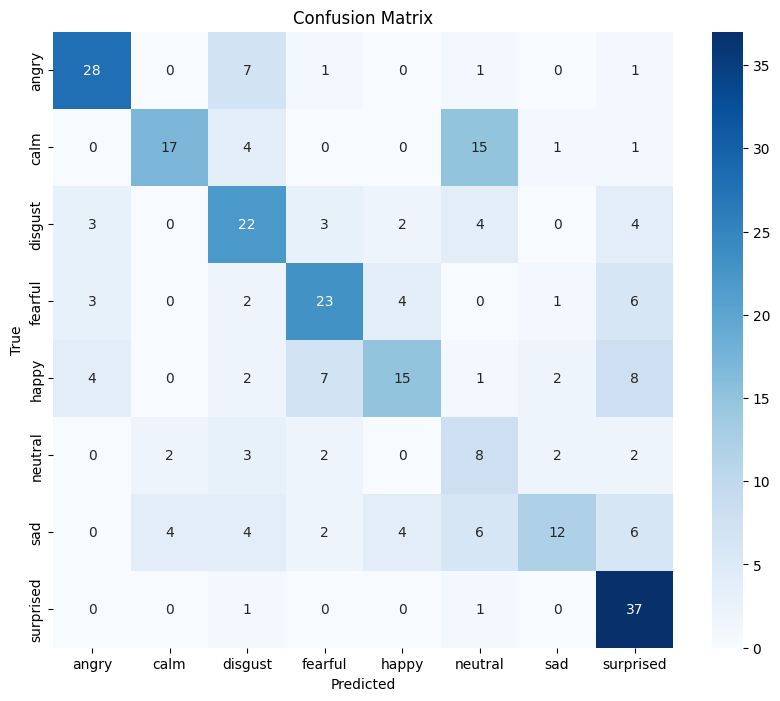

              precision    recall  f1-score   support

       angry       0.74      0.74      0.74        38
        calm       0.74      0.45      0.56        38
     disgust       0.49      0.58      0.53        38
     fearful       0.61      0.59      0.60        39
       happy       0.60      0.38      0.47        39
     neutral       0.22      0.42      0.29        19
         sad       0.67      0.32      0.43        38
   surprised       0.57      0.95      0.71        39

    accuracy                           0.56       288
   macro avg       0.58      0.55      0.54       288
weighted avg       0.60      0.56      0.56       288


Test File: 03-01-01-01-01-01-01.wav
Prediction: neutral (0.30)


In [11]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. CONFIGURATION
# ==========================================
CONFIG = {
    'dataset_path': r"E:\Extra_Work\SLITT\MySolution\AI\Training\Emotion_Voice_Datasets\RAVDESS", # UPDATE THIS PATH
    'sample_rate': 22050,
    'duration': 3,          # Fix audio to 3 seconds
    'n_mfcc': 40,           # Number of MFCC features
    'batch_size': 32,
    'epochs': 150,           # Increased epochs (Early Stopping will handle overtraining)
    'learning_rate': 0.001,
    'weight_decay': 1e-4,   # L2 Regularization
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

EMOTIONS = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================
def load_data(path):
    file_list = []
    label_list = []
    
    print("Scanning dataset...")
    for file in glob.glob(os.path.join(path, "**/*.wav"), recursive=True):
        filename = os.path.basename(file)
        parts = filename.split("-")
        
        if len(parts) == 7:
            emotion_code = parts[2]
            label = EMOTIONS.get(emotion_code)
            if label:
                file_list.append(file)
                label_list.append(label)
                
    return pd.DataFrame({'path': file_list, 'label': label_list})

def extract_features(file_path):
    """
    Extracts MFCC features. 
    Returns: (n_mfcc, time_steps)
    """
    target_len = CONFIG['sample_rate'] * CONFIG['duration']
    try:
        audio, sr = librosa.load(file_path, sr=CONFIG['sample_rate'], duration=CONFIG['duration'])
        
        # Pad or Truncate
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)), 'constant')
        else:
            audio = audio[:target_len]
            
        # Extract MFCCs
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=CONFIG['n_mfcc'])
        return mfcc
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

# --- Prepare Data ---
df = load_data(CONFIG['dataset_path'])
print(f"Found {len(df)} audio files.")

# Feature Extraction Loop
print("Extracting features...")
X_raw, valid_labels = [], []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
    feat = extract_features(row['path'])
    if feat is not None:
        X_raw.append(feat)
        valid_labels.append(row['label'])

X = np.array(X_raw)
y = np.array(valid_labels)

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standard Scaling (Fit on Train, Transform Test)
# Flatten to (N, Features) for scaler, then reshape back
scaler = StandardScaler()
N, C, T = X_train.shape
X_train = scaler.fit_transform(X_train.reshape(N, -1)).reshape(N, C, T)
X_test = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape[0], C, T)

print(f"Data Shapes -> Train: {X_train.shape}, Test: {X_test.shape}")

# ==========================================
# 3. PYTORCH DATASET
# ==========================================
class RAVDESSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = RAVDESSDataset(X_train, y_train)
test_dataset = RAVDESSDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, pin_memory=True)

# ==========================================
# 4. CRNN MODEL (CNN + GRU)
# ==========================================
class CRNNModel(nn.Module):
    def __init__(self, num_classes, input_channels=40, hidden_size=128, num_layers=2):
        super(CRNNModel, self).__init__()
        
        # 1. CNN Feature Extractor
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv1d(input_channels, 64, kernel_size=5, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3),
            
            # Block 2
            nn.Conv1d(64, 128, kernel_size=5, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3),
            
            # Block 3
            nn.Conv1d(128, 128, kernel_size=5, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3),
        )
        
        # 2. Recurrent Block (Bidirectional GRU)
        self.gru = nn.GRU(
            input_size=128, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True,
            dropout=0.3
        )
        
        # 3. Classifier
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, 40, Time)
        
        x = self.cnn(x) 
        # Output: (Batch, 128, Reduced_Time)
        
        # Prepare for GRU: (Batch, Time, Features)
        x = x.permute(0, 2, 1) 
        
        # GRU returns (output, h_n)
        output, _ = self.gru(x)
        
        # Global pooling: We take the mean of all time steps (better than just the last step)
        # This handles variable length context better
        x = torch.mean(output, dim=1)
        
        x = self.fc(x)
        return x

model = CRNNModel(num_classes=len(classes)).to(CONFIG['device'])

# ==========================================
# 5. TRAINING WITH EARLY STOPPING
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
scaler_amp = torch.cuda.amp.GradScaler() # For Mixed Precision Training

# Early Stopping Config
patience = 8
counter = 0
best_val_loss = float('inf')
best_acc = 0.0

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("\nStarting Training...")
for epoch in range(CONFIG['epochs']):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}", leave=False)
    
    for inputs, labels in loop:
        inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
        
        optimizer.zero_grad()
        
        # Mixed Precision Context
        with torch.cuda.amp.autocast(enabled=(CONFIG['device'] == 'cuda')):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        loop.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_epoch_loss = val_loss / len(test_loader)
    val_epoch_acc = val_correct / val_total
    
    # Store History
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_epoch_acc)
    
    # Scheduler Step
    scheduler.step(val_epoch_acc)
    
    # Print Stats
    print(f"Epoch {epoch+1}: Train Loss: {epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")
    
    # Checkpointing & Early Stopping
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        counter = 0
        torch.save(model.state_dict(), "best_crnn_model.pth") # Save best model
    else:
        counter += 1
        print(f"Early Stopping Counter: {counter}/{patience}")
        if counter >= patience:
            print("Early Stopping Triggered.")
            break

# ==========================================
# 6. EVALUATION
# ==========================================
print("\n--- Final Evaluation ---")
model.load_state_dict(torch.load("best_crnn_model.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(CONFIG['device'])
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

# ==========================================
# 7. INFERENCE FUNCTION
# ==========================================
def predict_emotion(audio_path):
    model.eval()
    
    # Extract
    mfcc = extract_features(audio_path)
    if mfcc is None: return "Error"
    
    # Scale (Re-use the fitted scaler)
    # (Channels, Time) -> Flatten -> Scale -> Reshape
    C, T = mfcc.shape
    mfcc_flat = mfcc.reshape(-1).reshape(1, -1)
    mfcc_scaled = scaler.transform(mfcc_flat).reshape(1, C, T)
    
    # Convert to Tensor
    input_tensor = torch.tensor(mfcc_scaled, dtype=torch.float32).to(CONFIG['device'])
    
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        conf, idx = torch.max(probs, 1)
        
    return classes[idx.item()], conf.item()

# Test
if len(df) > 0:
    sample = df.iloc[0]['path']
    pred, conf = predict_emotion(sample)
    print(f"\nTest File: {os.path.basename(sample)}")
    print(f"Prediction: {pred} ({conf:.2f})")

In [13]:
pip install evaluate soundfile


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import torch
import evaluate
from sklearn.model_selection import train_test_split
from datasets import Dataset, Audio, ClassLabel, Features
from transformers import (
    AutoConfig,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# ==========================================
# 1. CONFIGURATION
# ==========================================
CONFIG = {
    'dataset_path': r"E:\Extra_Work\SLITT\MySolution\AI\Training\Emotion_Voice_Datasets\RAVDESS", # UPDATE THIS PATH
    'model_checkpoint': "facebook/wav2vec2-base",
    'target_sr': 16000,     
    'batch_size': 4,        
    'epochs': 20,            
    'learning_rate': 3e-5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Using device: {CONFIG['device']}")

# Emotion Map (RAVDESS)
EMOTIONS = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

# ==========================================
# 2. DATA LOADING & PROCESSING
# ==========================================
def load_data(path):
    paths = []
    labels = []
    # Recursively find all .wav files
    for file in glob.glob(os.path.join(path, "**/*.wav"), recursive=True):
        filename = os.path.basename(file)
        parts = filename.split("-")
        if len(parts) == 7:
            label = EMOTIONS.get(parts[2])
            if label:
                paths.append(file)
                labels.append(label)
    return pd.DataFrame({'path': paths, 'label': labels})

print("Loading Data...")
df = load_data(CONFIG['dataset_path'])

# Create Class Labels for Hugging Face
label_list = sorted(list(set(df['label'])))
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

df['label'] = df['label'].map(label2id)

# Split (Stratified)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Convert to HF Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Initialize Feature Extractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(CONFIG['model_checkpoint'])

def preprocess_function(examples):
    audio_arrays = []
    for path in examples['path']:
        # Load and resample to 16kHz
        speech, _ = librosa.load(path, sr=CONFIG['target_sr'])
        audio_arrays.append(speech)
        
    # Feature Extractor call
    inputs = feature_extractor(
        audio_arrays, 
        sampling_rate=CONFIG['target_sr'], 
        padding=True, 
        max_length=CONFIG['target_sr']*3, # Cap at 3 seconds to save memory
        truncation=True
    )
    return inputs

print("Preprocessing Audio (this extracts features)...")
# batched=True is crucial for speed
train_encoded = train_dataset.map(preprocess_function, batched=True, batch_size=4)
test_encoded = test_dataset.map(preprocess_function, batched=True, batch_size=4)

# ==========================================
# 3. METRICS
# ==========================================
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    # eval_pred is a tuple (logits, labels)
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return metric.compute(predictions=predictions, references=labels)

# ==========================================
# 4. MODEL SETUP
# ==========================================
num_labels = len(label_list)
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    CONFIG['model_checkpoint'], 
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label
)

# Freeze feature encoder to speed up training
model.freeze_feature_encoder()

# ==========================================
# 5. TRAINING ARGUMENTS (FIXED)
# ==========================================
training_args = TrainingArguments(
    output_dir="./wav2vec2_emotion",
    
    # Updated Argument Names
    eval_strategy="epoch",  # WAS evaluation_strategy
    save_strategy="epoch",
    
    learning_rate=CONFIG['learning_rate'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'],
    num_train_epochs=CONFIG['epochs'],
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    logging_steps=10,
    
    # Use Mixed Precision if GPU is available
    fp16=(CONFIG['device'] == 'cuda'), 
)

# Trainer Initialization (FIXED)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=test_encoded,
    
    # CHANGED HERE: tokenizer -> processing_class
    # In newer transformers, 'tokenizer' is deprecated for audio models. 
    # Use 'processing_class' or simply pass feature_extractor as 'tokenizer' 
    # if you are on an older version, but 'processing_class' is the future-proof way.
    processing_class=feature_extractor, 
    
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# ==========================================
# 6. TRAINING
# ==========================================
print("Starting Training...")
trainer.train()

print("\nFinal Evaluation:")
stats = trainer.evaluate()
print(f"Accuracy: {stats['eval_accuracy']:.4f}")

# Save the full model
model.save_pretrained("./best_wav2vec_model")
feature_extractor.save_pretrained("./best_wav2vec_model")

# ==========================================
# 7. QUANTIZATION (SPEED UP INFERENCE)
# ==========================================
print("\n--- Applying Dynamic Quantization ---")
import torch.quantization

# 1. Load the fine-tuned model (CPU is required for quantization usually)
model_fp32 = Wav2Vec2ForSequenceClassification.from_pretrained("./best_wav2vec_model").to("cpu")

# 2. Quantize (Convert weights to Int8)
quantized_model = torch.quantization.quantize_dynamic(
    model_fp32,
    {torch.nn.Linear},  # Quantize Linear layers
    dtype=torch.qint8
)

# 3. Save Quantized Model
torch.save(quantized_model.state_dict(), "quantized_emotion_model.pth")
print("Quantized model saved! Size reduced significantly.")



Using device: cuda
Loading Data...
Preprocessing Audio (this extracts features)...


Map:   0%|          | 0/1152 [00:00<?, ? examples/s]

Map:   0%|          | 0/288 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Applying Dynamic Quantization ---


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

C:\Users\LOQ\AppData\Local\Temp\ipykernel_16804\1970365276.py:189: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Quantized model saved! Size reduced significantly.


In [2]:
# ==========================================
# 8. FAST INFERENCE FUNCTION
# ==========================================
def predict_emotion_quantized(audio_path):
    # Load configuration
    config = AutoConfig.from_pretrained("./best_wav2vec_model")
    
    # Re-initialize architecture
    model = Wav2Vec2ForSequenceClassification(config)
    
    # Load Quantized Weights
    # NOTE: You must prepare the model for quantization BEFORE loading the state dict
    model = torch.quantization.quantize_dynamic(
        model, {torch.nn.Linear}, dtype=torch.qint8
    )
    model.load_state_dict(torch.load("quantized_emotion_model.pth"))
    model.eval()
    
    # Process Audio
    speech, _ = librosa.load(audio_path, sr=16000)
    inputs = feature_extractor(speech, sampling_rate=16000, return_tensors="pt", padding=True)
    
    # Predict
    with torch.no_grad():
        logits = model(**inputs).logits
        
    pred_id = torch.argmax(logits, dim=-1).item()
    confidence = torch.nn.functional.softmax(logits, dim=-1).max().item()
    
    return config.id2label[pred_id], confidence

# Test
if len(test_df) > 0:
    import time
    sample_file = r"E:\Extra_Work\SLITT\MySolution\AI\Training\output_song.wav"
    
    start = time.time()
    pred, conf = predict_emotion_quantized(sample_file)
    end = time.time()
    
    print(f"\nTest File: {os.path.basename(sample_file)}")
    print(f"Prediction: {pred} ({conf:.2f})")
    print(f"Inference Time (CPU): {(end-start)*1000:.2f} ms")

C:\Users\LOQ\AppData\Local\Temp\ipykernel_16804\3079578236.py:13: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model = torch.quantization.quantize_dynamic(
c:\Users\LOQ\anaconda3\envs\medgemma\Lib\site-packages\torch\_utils.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should onl


Test File: output_song.wav
Prediction: fearful (1.00)
Inference Time (CPU): 4016.87 ms


In [1]:
pip install torch pillow gradio


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/24.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.2 MB ? eta -:--:--
    --------------------------------------- 0.5/24.2 MB 984.0 kB/s eta 0:00:25
   - -------------------------------------- 0.8/24.2 MB 965.9 kB/s eta 0:00:25
   - -------------------------------------- 1.0/24.2 MB 1.0 MB/s eta 0:00:23
   -- ------------------------------------- 1.3/24.2 MB 1.1 MB/s eta 0:00:22
   -- ------------------------------------- 1.6/24.2 MB 1.1 MB/s eta 0:00:21
   --- ------------------------------------ 1.8/24.2 MB 1.2 MB/s eta 0:00:19
   --- ------------------------------------ 2.4/24.2 MB 1.3 MB/s eta 0:00:17
   ---- ----------------------------------- 2.6/24.2 MB 1.3 MB/s eta 0:00:17
   ----- ----------------------

In [2]:
import gradio as gr
from transformers import AutoImageProcessor, SiglipForImageClassification
from PIL import Image
import torch

# Load model and processor
model_name = "prithivMLmods/Realistic-Gender-Classification"
model = SiglipForImageClassification.from_pretrained(model_name)
processor = AutoImageProcessor.from_pretrained(model_name)

# ID to label mapping
id2label = {
    "0": "female portrait",
    "1": "male portrait"
}

def classify_gender(image):
    image = Image.fromarray(image).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1).squeeze().tolist()

    prediction = {id2label[str(i)]: round(probs[i], 3) for i in range(len(probs))}
    return prediction

# Gradio Interface
iface = gr.Interface(
    fn=classify_gender,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=2, label="Gender Classification"),
    title="Realistic-Gender-Classification",
    description="Upload a realistic portrait image to classify it as 'female portrait' or 'male portrait'."
)

if __name__ == "__main__":
    iface.launch()


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
